<a href="https://colab.research.google.com/github/GuanghuaShi/Tennis-Shot-Recognition/blob/main/Tennis_Recognition_Baseline_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Data Preparation
### Clone GitHub Repo in Colab

In [1]:
!git clone https://github.com/Nelijahk/3DCNN-Tennis-Action-Recognition.git

Cloning into '3DCNN-Tennis-Action-Recognition'...
remote: Enumerating objects: 417, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 417 (delta 14), reused 3 (delta 0), pack-reused 390 (from 1)
Receiving objects: 100% (417/417), 264.75 MiB | 30.74 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Updating files: 100% (381/381), done.


### Get the list of action classes (labels) in dataset

In [2]:
import os

base_path = "/content/3DCNN-Tennis-Action-Recognition/tennis_dataset"
class_names = sorted(os.listdir(base_path))

print(class_names)

['b_slice', 'b_volley', 'backhand', 'f_volley', 'forehand', 'serve', 'smash']


### Build Dataset List

builds a dataset list of video file paths with their corresponding numeric labels.

In [3]:
dataset = []

for label, class_name in enumerate(class_names):
    class_dir = os.path.join(base_path, class_name)

    for file in os.listdir(class_dir):
        if file.endswith((".mp4", ".avi")):
            dataset.append((os.path.join(class_dir, file), label))

print("Total samples:", len(dataset))

Total samples: 371


### Split the dataset into Train / Val / Test

We split the dataset into Train/ Validation/ Test: 70 / 15 / 15

In [4]:
from sklearn.model_selection import train_test_split

# extract labels for stratification
labels = [y for _, y in dataset]

# first split: train (70) + temp (30)
train_data, temp_data = train_test_split(
    dataset, test_size=0.3, random_state=42, stratify=labels
)

# second split: val (15) + test (15)
temp_labels = [y for _, y in temp_data]

val_data, test_data = train_test_split(
    temp_data, test_size=0.5, random_state=42, stratify=temp_labels
)

print("Train:", len(train_data))
print("Val:", len(val_data))
print("Test:", len(test_data))

Train: 259
Val: 56
Test: 56


### Store the split dataset.

In [5]:
import json

splits = {
    "train": train_data,
    "val": val_data,
    "test": test_data
}

with open("data_splits.json", "w") as f:
    json.dump(splits, f)

In [6]:
import pickle

with open('train_data.pkl', 'wb') as f:
    pickle.dump(train_data, f)

with open('val_data.pkl', 'wb') as f:
    pickle.dump(val_data, f)

with open('test_data.pkl', 'wb') as f:
    pickle.dump(test_data, f)

print("Train, Validation, and Test datasets saved as train_data.pkl, val_data.pkl, and test_data.pkl")

Train, Validation, and Test datasets saved as train_data.pkl, val_data.pkl, and test_data.pkl


## 2. Feature Extraction

### Extract Frame (middle frame)

Turn a video into an image input for models. Extracts a single representative frame (the middle frame) from a video and preprocesses it.

Briefly:

* Opens the video
* Finds the middle frame
* Resizes it to a fixed size (224×224)
* Converts it to RGB format
* Returns the processed image

In [15]:
import cv2

def extract_middle_frame(video_path, size=(224, 224)):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total == 0:
        cap.release()
        return None

    cap.set(cv2.CAP_PROP_POS_FRAMES, total // 2)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        return None

    frame = cv2.resize(frame, size)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return frame

### Load Pretrained ResNet-18

In [16]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms

device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet18(pretrained=True)
model.fc = torch.nn.Identity()  # remove classifier
model = model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Extract Features

Extract feature vectors from videos for a classifier.
* For each video, get the middle frame
* Apply preprocessing (transform) and sends it to the model
* Uses a pretrained model to extract features (not predictions)
* Stores:
 * * X = feature vectors
 * * y = labels

In [17]:
import numpy as np
from tqdm import tqdm

def extract_features(data):
    X, y = [], []

    for video_path, label in tqdm(data):
        frame = extract_middle_frame(video_path)

        if frame is None:
            continue

        img = transform(frame).unsqueeze(0).to(device)

        with torch.no_grad():
            feat = model(img).cpu().numpy().flatten()

        X.append(feat)
        y.append(label)

    return np.array(X), np.array(y)

# extract features for all splits
X_train, y_train = extract_features(train_data)
X_val, y_val     = extract_features(val_data)
X_test, y_test   = extract_features(test_data)

100%|██████████| 56/56 [00:05<00:00,  9.49it/s]


## 3. Train Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

best_acc = 0
best_C = None

for C in [0.01, 0.1, 1, 10, 100]:
    clf = LogisticRegression(C=C, max_iter=1000)
    clf.fit(X_train, y_train)

    y_val_pred = clf.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)

    print(f"C={C}, Val Accuracy={acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_C = C

print("Best C:", best_C)

C=0.01, Val Accuracy=0.7857
C=0.1, Val Accuracy=0.8214
C=1, Val Accuracy=0.7857
C=10, Val Accuracy=0.7857
C=100, Val Accuracy=0.8036
Best C: 0.1


In [19]:
# combine train + val
X_trainval = np.concatenate([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

final_model = LogisticRegression(C=best_C, max_iter=1000)
final_model.fit(X_trainval, y_trainval)

LogisticRegression(C=0.1, max_iter=1000)

## 4. Evaluation

In [20]:
y_test_pred = final_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print("Final Test Accuracy:", test_acc)

Final Test Accuracy: 0.8214285714285714


In [21]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

     b_slice       0.86      0.75      0.80         8
    b_volley       0.67      0.75      0.71         8
    backhand       0.86      0.75      0.80         8
    f_volley       0.70      0.88      0.78         8
    forehand       1.00      0.88      0.93         8
       serve       0.86      0.75      0.80         8
       smash       0.89      1.00      0.94         8

    accuracy                           0.82        56
   macro avg       0.83      0.82      0.82        56
weighted avg       0.83      0.82      0.82        56



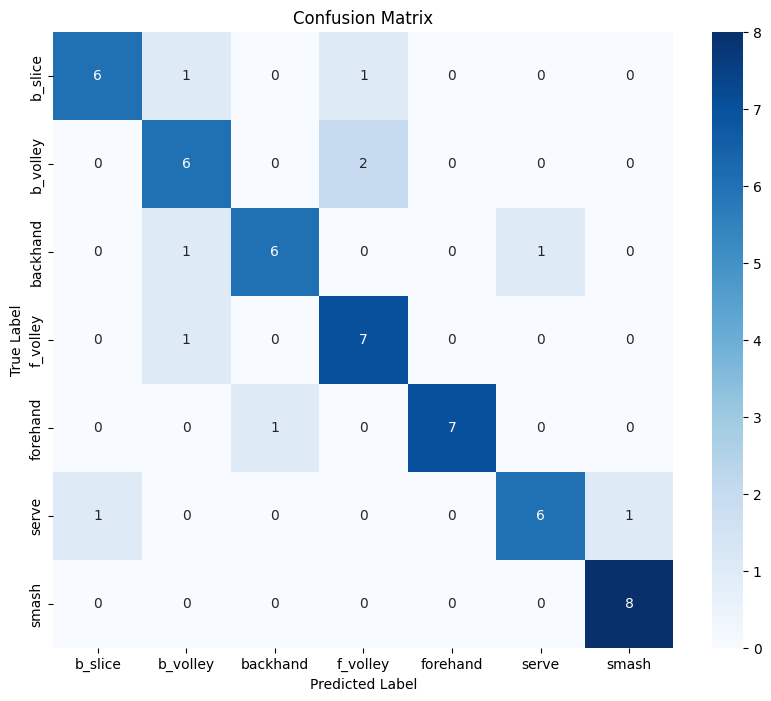

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()